In [ ]:
!nvidia-smi

Sun Feb 15 10:59:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   74C    P0             40W /   70W |    5419MiB /  15360MiB |     45%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
# from sklearn.linear_model import Perceptron
# import tensorflow as tf
# from tensorflow.keras import layers
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from tensorflow.keras.layers import Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.utils import to_categorical


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset :", path)

Using Colab cache for faster access to the 'lgg-mri-segmentation' dataset.
Path to dataset : /kaggle/input/lgg-mri-segmentation


In [ ]:
import os
os.listdir(path)

['kaggle_3m', 'lgg-mri-segmentation']

In [ ]:
import pandas as pd
import glob
import os

data_dir = '/kaggle/input/lgg-mri-segmentation/kaggle_3m/'
# Get all file paths for images and masks
# The dataset structure is: patient_folder/image_name.tif and patient_folder/image_name_mask.tif
filenames = glob.glob(data_dir + '**/*.tif', recursive=True)

# Separate images from masks
# Masks always contain the string '_mask'
mask_files = [f for f in filenames if '_mask' in f]
image_files = [f for f in filenames if '_mask' not in f]

# Create a DataFrame
df = pd.DataFrame({
    'image_path': image_files,
    # This logic matches the image with its corresponding mask by adding '_mask' to the filename
    'mask_path': [f.replace('.tif', '_mask.tif') for f in image_files]
})

print(f"Total images found: {len(df)}")
df.head()

Total images found: 3929


,image_path,mask_path
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [ ]:
df

,image_path,mask_path
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
...,...,...
3924,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3925,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3926,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3927,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  3929 non-null   object
 1   mask_path   3929 non-null   object
dtypes: object(2)
memory usage: 61.5+ KB


In [ ]:
# Load the patient metadata
patient_df = pd.read_csv(data_dir + 'data.csv')

# Let's see what's inside
print("Patient Data Shape:", patient_df.shape)
patient_df.head()

Patient Data Shape: (110, 18)


,Patient,RNASeqCluster,MethylationCluster,miRNACluster,CNCluster,RPPACluster,OncosignCluster,COCCluster,histological_type,neoplasm_histologic_grade,tumor_tissue_site,laterality,tumor_location,gender,age_at_initial_pathologic,race,ethnicity,death01
0,TCGA_CS_4941,2.0,4.0,2,2.0,NaN,3.0,2,1.0,2.0,1.0,3.0,2.0,2.0,67.0,3.0,2.0,1.0
1,TCGA_CS_4942,1.0,5.0,2,1.0,1.0,2.0,1,1.0,2.0,1.0,3.0,2.0,1.0,44.0,2.0,NaN,1.0
2,TCGA_CS_4943,1.0,5.0,2,1.0,2.0,2.0,1,1.0,2.0,1.0,1.0,2.0,2.0,37.0,3.0,NaN,0.0
3,TCGA_CS_4944,NaN,5.0,2,1.0,2.0,1.0,1,1.0,1.0,1.0,3.0,6.0,2.0,50.0,3.0,NaN,0.0
4,TCGA_CS_5393,4.0,5.0,2,1.0,2.0,3.0,1,1.0,2.0,1.0,1.0,6.0,2.0,39.0,3.0,NaN,0.0


In [ ]:
df['patient_id']=df['image_path'].apply(lambda x: x.split('/')[-2])
df.head()

,image_path,mask_path,patient_id
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,TCGA_DU_7010_19860307


2.1 Critical Data Engineering Constraints
Standard “random split” methods are strictly prohibited due to high risk of data leakage. Subject-Level Splitting (Mandatory):
The dataset contains multiple slices per patient. Slices must be split by Patient ID. If slices from Patient A appear in both Train and Test sets, the model effectively “memorizes” the patient’s anatomy, rendering evaluation invalid.

In [ ]:
unique_patients = df['patient_id'].unique()

train_patients, test_val_patients = train_test_split(unique_patients, test_size=0.3,random_state=42,)
val_patients, test_patients = train_test_split(test_val_patients,test_size=0.5,random_state=42)

train_df = df[df['patient_id'].isin(train_patients)].reset_index(drop=True)
val_df= df[df['patient_id'].isin(val_patients)].reset_index(drop=True)
test_df = df[df['patient_id'].isin(test_patients)].reset_index(drop=True)

print(f"Splitting Complete:")
print(f"- Training: {len(train_df)} slices ({len(train_patients)} patients)")
print(f"- Validation: {len(val_df)} slices ({len(val_patients)} patients)")
print(f"- Testing: {len(test_df)} slices ({len(test_patients)} patients)")

Splitting Complete:
- Training: 2801 slices (77 patients)
- Validation: 567 slices (16 patients)
- Testing: 561 slices (17 patients)


VIsualizing the tumours

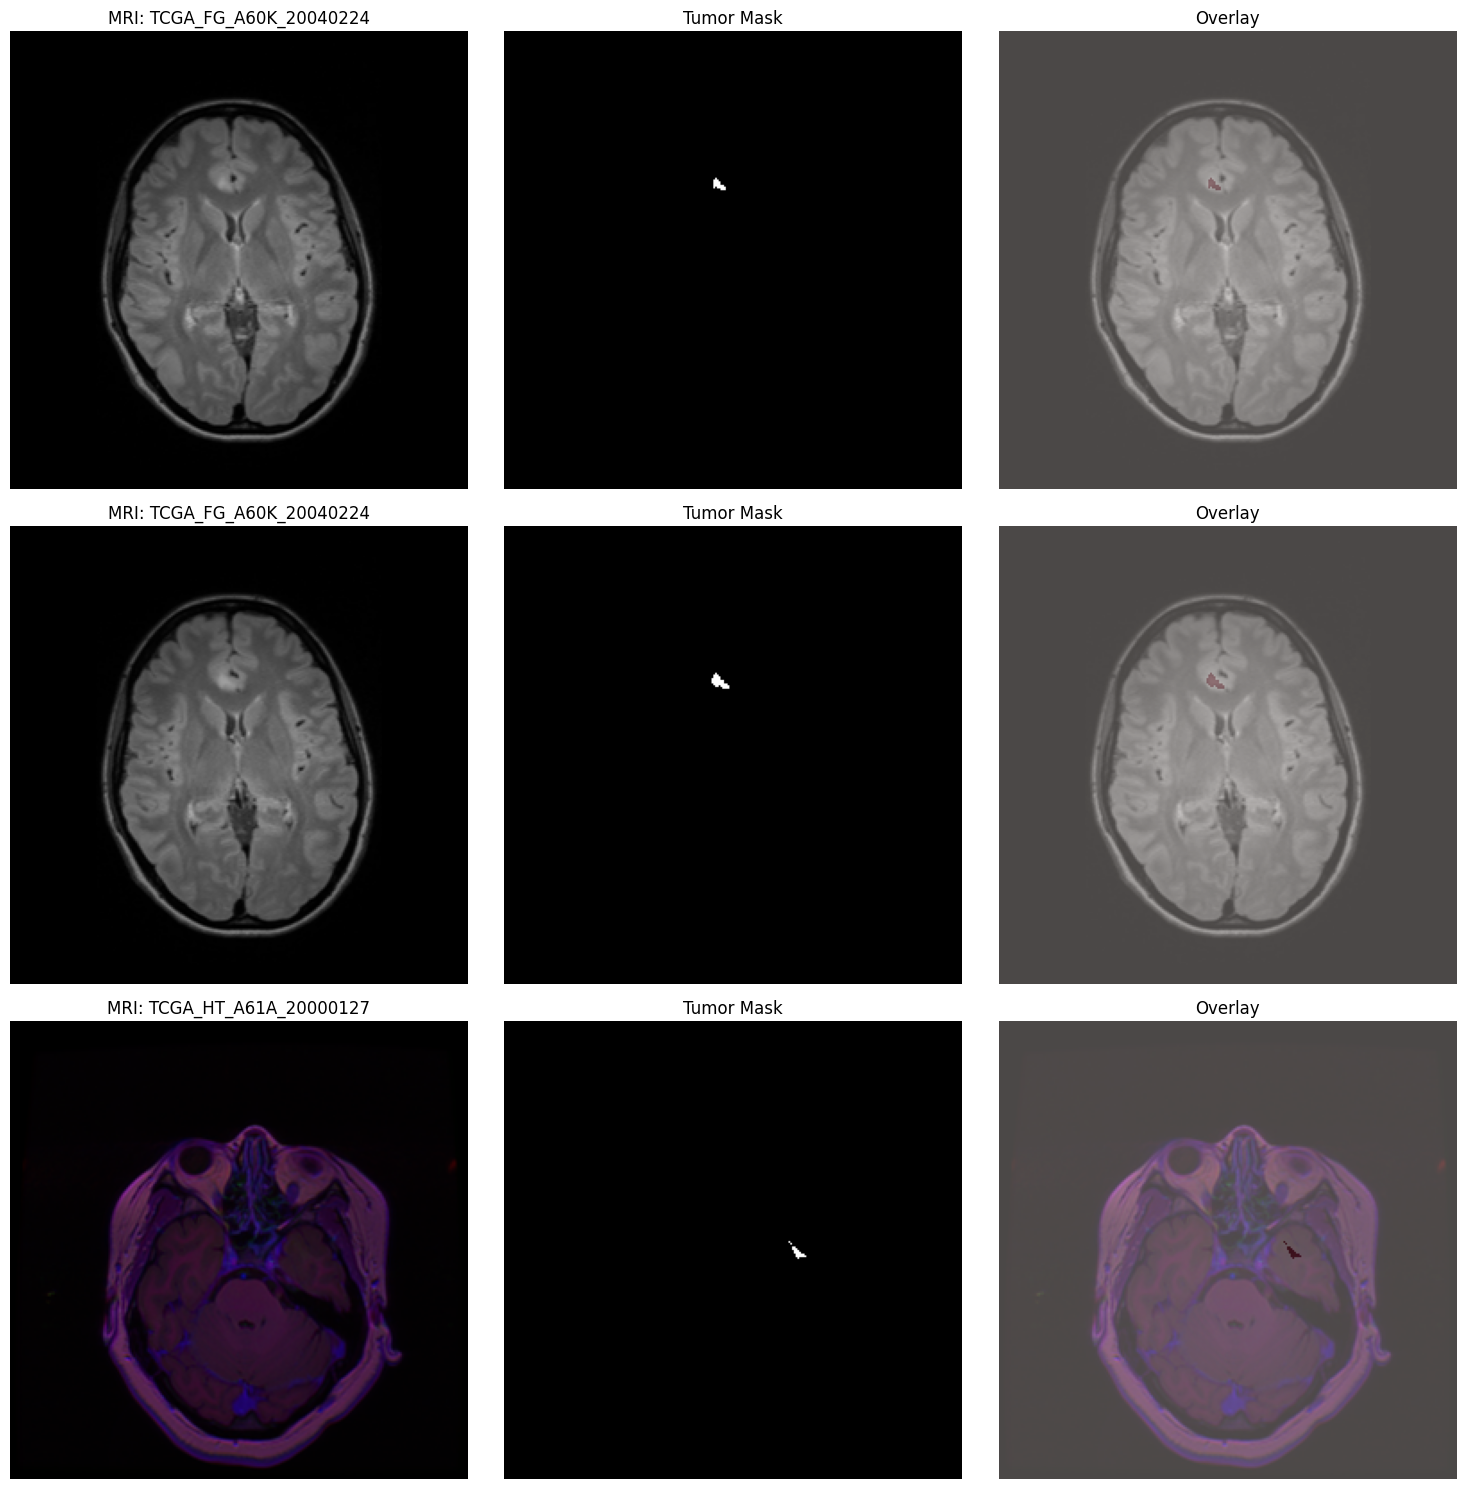

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

def visualize_mri_samples(df, num_samples=3):
    # Filter for slices that actually have a tumor (mask max value > 0)
    # This ensures we aren't just looking at empty black masks
    tumor_slices = df[df['mask_path'].apply(lambda x: cv2.imread(x, 0).max() > 0)]

    # Pick random samples from the tumor slices
    samples = tumor_slices.sample(num_samples)

    plt.figure(figsize=(15, 5 * num_samples))

    for i, (idx, row) in enumerate(samples.iterrows()):
        # Load Image
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Load Mask
        mask = cv2.imread(row['mask_path'], 0)

        # Plot Original MRI
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title(f"MRI: {row['patient_id']}")
        plt.axis('off')

        # Plot Mask
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(mask, cmap='gray')
        plt.title("Tumor Mask")
        plt.axis('off')

        # Plot Overlay (MRI + Mask)
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(img)
        plt.imshow(mask, alpha=0.3, cmap='Reds') # Overlay red mask with transparency
        plt.title("Overlay")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization on your training set
visualize_mri_samples(train_df)

Strict Data Augmentation:
Medical data is sparse; validation scores without augmentation are statistically insignificant.

• Required Transforms: Elastic deformation, Rotation (±15◦), Horizontal Flip, Brightness Jitter.

• Implementation Rule: Augmentations must be deterministic and paired. If the MRI rotates 10◦, the Ground Truth Mask must rotate exactly10◦.

In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

img_size=384
train_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.GridDistortion(p=0.3),
    A.GaussNoise(p=0.2),
    A.CLAHE(p=0.3),
    A.Normalize(mean=(0.5,), std=(0.2,)),
    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=(0.5,), std=(0.2,)),
    ToTensorV2()
])

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np

# Also define DEVICE here to prevent the previous error from coming back
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
class Neuroseg(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['image_path']
        mask_path = self.df.iloc[idx]['mask_path']

        # 1. Read files
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        # 2. Apply transforms
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # 3. Final Conversion Check
        # If ToTensorV2() was used, these are already Tensors.
        # If not, we convert them here.
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image).float().unsqueeze(0)

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).float().unsqueeze(0)

        # 4. Ensure shape is (1, H, W) even if ToTensorV2 was used
        if image.ndimension() == 2:
            image = image.unsqueeze(0)
        if mask.ndimension() == 2:
            mask = mask.unsqueeze(0)

        return image, mask

In [ ]:
train_dataset=Neuroseg(train_df,transform=train_transform)
val_dataset=Neuroseg(val_df,transform=val_transform)

train_loader=DataLoader(train_dataset,
                        batch_size=16,
                        shuffle=True,
                        num_workers=4,
                        pin_memory=True)

val_loader=DataLoader(val_dataset,
                      batch_size=16,
                      shuffle=False,
                      num_workers=4,
                      pin_memory=True)

print(f"Dataset established. Batch size: 16")
print(f"Sample Image shape: {train_dataset[0][0].shape}")

Dataset established. Batch size: 16
Sample Image shape: torch.Size([1, 384, 384])


In [ ]:
def check_data_alignment(dataset, num_samples=3):
    plt.figure(figsize=(10, 10))
    for i in range(num_samples):
        img, msk = dataset[i]

        # Fix: If img is (3, 256, 256), take only the first channel [0, :, :]
        # Then denormalize
        if img.shape[0] == 3:
            img_to_plot = img[0, :, :].numpy() * 0.5 + 0.5
        else:
            img_to_plot = img.squeeze().numpy() * 0.5 + 0.5

        msk_to_plot = msk.squeeze().numpy()

        plt.subplot(2, num_samples, i + 1)
        plt.imshow(img_to_plot, cmap='gray')
        plt.title("MRI Scan")
        plt.axis('off')

        plt.subplot(2, num_samples, i + 1 + num_samples)
        plt.imshow(msk_to_plot, cmap='Reds', alpha=0.7)
        plt.title(f"Aligned Mask {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
import torch

# Define the device variable
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
pip install segmentation-models-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.9 MB/s eta 0:00:00


In [ ]:
!pip install torchinfo


In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
).to(DEVICE)


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

In [ ]:
from torchinfo import summary

summary(
    model,
    input_size=(1, 1, 384, 384),  # (batch, channels, height, width)
    col_names=["input_size", "output_size", "num_params"],
    depth=3
)


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
Unet                                          [1, 1, 384, 384]          [1, 1, 384, 384]          --
├─ResNetEncoder: 1-1                          [1, 1, 384, 384]          [1, 1, 384, 384]          --
│    └─Conv2d: 2-1                            [1, 1, 384, 384]          [1, 64, 192, 192]         3,136
│    └─BatchNorm2d: 2-2                       [1, 64, 192, 192]         [1, 64, 192, 192]         128
│    └─ReLU: 2-3                              [1, 64, 192, 192]         [1, 64, 192, 192]         --
│    └─MaxPool2d: 2-4                         [1, 64, 192, 192]         [1, 64, 96, 96]           --
│    └─Sequential: 2-5                        [1, 64, 96, 96]           [1, 64, 96, 96]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 96, 96]           [1, 64, 96, 96]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 96, 96]           [1, 64

In [ ]:
# import torch.nn as nn
# class UNet(nn.Module):
#     def __init__(self, in_channels=1, out_channels=1):

#         super(UNet, self).__init__()
#         def conv_block(in_c, out_c):
#             return nn.Sequential(

#                 nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_c),
#                 nn.ReLU(inplace=True),
#                 nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
#                 nn.BatchNorm2d(out_c),
#                 nn.ReLU(inplace=True)
#             )
#         # Encoder (Downsampling)

#         self.enc1 = conv_block(in_channels, 64)
#         self.enc2 = conv_block(64, 128)
#         self.enc3 = conv_block(128, 256)
#         self.enc4 = conv_block(256, 512)

#         self.pool = nn.MaxPool2d(2)
#         # Bottleneck

#         self.bottleneck = conv_block(512, 1024)
#         # Decoder (Upsampling)

#         self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
#         self.dec4 = conv_block(1024, 512) # 512 (from up) + 512 (from skip)

#         self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
#         self.dec3 = conv_block(512, 256)

#         self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
#         self.dec2 = conv_block(256, 128)

#         self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
#         self.dec1 = conv_block(128, 64)
#         # Output Layer
#         self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

#     def forward(self, x):
#         # Encoder
#         s1 = self.enc1(x)
#         p1 = self.pool(s1)
#         s2 = self.enc2(p1)
#         p2 = self.pool(s2)
#         s3 = self.enc3(p2)
#         p3 = self.pool(s3)
#         s4 = self.enc4(p3)
#         p4 = self.pool(s4)

#         # Bottleneck

#         b = self.bottleneck(p4)

#         # Decoder with Skip Connections

#         d4 = self.up4(b)
#         d4 = torch.cat((d4, s4), dim=1) # Concatenate
#         d4 = self.dec4(d4)

#         d3 = self.up3(d4)
#         d3 = torch.cat((d3, s3), dim=1)
#         d3 = self.dec3(d3)


#         d2 = self.up2(d3)
#         d2 = torch.cat((d2, s2), dim=1)
#         d2 = self.dec2(d2)

#         d1 = self.up1(d2)
#         d1 = torch.cat((d1, s1), dim=1)
#         d1 = self.dec1(d1)



#         return self.final_conv(d1)
# # Initialize model

# model = UNet(in_channels=1, out_channels=1).to(DEVICE)

# print("U-Net Architecture initialized.")

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# Metric calculation function (KPIs)
def get_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    # Apply sigmoid if not already applied in the model
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()
    targets = (targets > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    intersection = (preds * targets).sum()
    total = preds.sum() + targets.sum()
    union = (preds + targets).sum() - intersection

    dice = (2. * intersection + smooth) / (total + smooth)
    iou = (intersection + smooth) / (union + smooth)

    # Sensitivity/Recall
    sensitivity = (intersection + smooth) / (targets.sum() + smooth)

    return dice.item(), iou.item(), sensitivity.item()



# Metadata calculation (Surface Area)
def calculate_tumor_area(mask, threshold=0.5):
    binary_mask = (mask > threshold).float()
    return torch.sum(binary_mask).item()

In [ ]:
# Specialized Loss for Segmentation
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds) # Ensure values are 0-1
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, preds, targets):
        bce = self.bce(preds, targets)
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()


In [ ]:
class CombinedLoss(nn.Module):
    def __init__(self, w_bce=1.0, w_dice=1.0, w_focal=1.0):
        super().__init__()

        # Loss modules
        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = DiceLoss()
        self.focal_loss = FocalLoss(alpha=0.8, gamma=2)

        # Scalar weights
        self.w_bce = w_bce
        self.w_dice = w_dice
        self.w_focal = w_focal

    def forward(self, preds, targets):
        loss_bce = self.bce_loss(preds, targets)
        loss_dice = self.dice_loss(preds, targets)
        loss_focal = self.focal_loss(preds, targets)

        return (
            self.w_bce * loss_bce +
            self.w_dice * loss_dice +
            self.w_focal * loss_focal
        )


In [ ]:
import cv2

def post_process_mask(mask):
    # mask: numpy array (H, W)
    kernel = np.ones((3,3), np.uint8)
    # Removes small white noise (opening)
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return cleaned_mask

In [ ]:
from tqdm import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3
)

In [ ]:
criterion = CombinedLoss(
    w_bce=0.5,
    w_dice=1.0,
    w_focal=0.5
)

num_epochs = 25
best_val_dice = 0.0
early_stop_counter = 0
early_stop_patience = 8


In [ ]:
train_losses = []
val_losses = []
train_dices = []
val_dices = []


for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    model.train()
    train_loss = 0.0
    train_dice = 0.0

    for images, masks in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        dice, _, _ = get_metrics(outputs, masks)

        train_loss += loss.item()
        train_dice += dice

    train_loss /= len(train_loader)
    train_dice /= len(train_loader)

    # ✅ STORE TRAIN METRICS
    train_losses.append(train_loss)
    train_dices.append(train_dice)

    model.eval()
    val_loss = 0.0
    val_dice = 0.0
    val_iou = 0.0
    val_sensitivity = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Validation", leave=False):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)

            dice, iou, sens = get_metrics(outputs, masks)

            val_loss += loss.item()
            val_dice += dice
            val_iou += iou
            val_sensitivity += sens

    val_loss /= len(val_loader)
    val_dice /= len(val_loader)
    val_iou /= len(val_loader)
    val_sensitivity /= len(val_loader)

    # ✅ STORE VAL METRICS
    val_losses.append(val_loss)
    val_dices.append(val_dice)

    print(f"Train Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Dice:   {val_dice:.4f}")
    print(f"Val IoU:    {val_iou:.4f} | Val Sens:  {val_sensitivity:.4f}")

    scheduler.step(val_dice)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_unet_model.pth")
        print("✅ Best model saved")
        early_stop_counter = 0
    else:
        early_stop_counter += 1

    if early_stop_counter >= early_stop_patience:
        print("⛔ Early stopping triggered")
        break



Epoch [1/25]


Train Loss: 1.2650 | Train Dice: 0.2734
Val Loss:   1.1535 | Val Dice:   0.4860
Val IoU:    0.3616 | Val Sens:  0.5779
✅ Best model saved

Epoch [2/25]


Train Loss: 1.0980 | Train Dice: 0.5069
Val Loss:   1.0124 | Val Dice:   0.6080
Val IoU:    0.4685 | Val Sens:  0.6955
✅ Best model saved

Epoch [3/25]


Train Loss: 0.9941 | Train Dice: 0.5374
Val Loss:   0.8921 | Val Dice:   0.6427
Val IoU:    0.5294 | Val Sens:  0.6420
✅ Best model saved

Epoch [4/25]


Train Loss: 0.8506 | Train Dice: 0.5587
Val Loss:   0.7159 | Val Dice:   0.6284
Val IoU:    0.5041 | Val Sens:  0.6839

Epoch [5/25]


...

Train Loss: 0.2217 | Train Dice: 0.8018
Val Loss:   0.2434 | Val Dice:   0.7829
Val IoU:    0.6934 | Val Sens:  0.7689

Epoch [22/25]


Train Loss: 0.2432 | Train Dice: 0.7803
Val Loss:   0.2508 | Val Dice:   0.7764
Val IoU:    0.6785 | Val Sens:  0.7641

Epoch [23/25]


Train Loss: 0.2139 | Train Dice: 0.8086
Val Loss:   0.2527 | Val Dice:   0.7744
Val IoU:    0.6824 | Val Sens:  0.7560

Epoch [24/25]


Train Loss: 0.2405 | Train Dice: 0.7839
Val Loss:   0.2459 | Val Dice:   0.7798
Val IoU:    0.6893 | Val Sens:  0.7643

Epoch [25/25]


Train Loss: 0.2128 | Train Dice: 0.8152
Val Loss:   0.2593 | Val Dice:   0.7675
Val IoU:    0.6766 | Val Sens:  0.7542


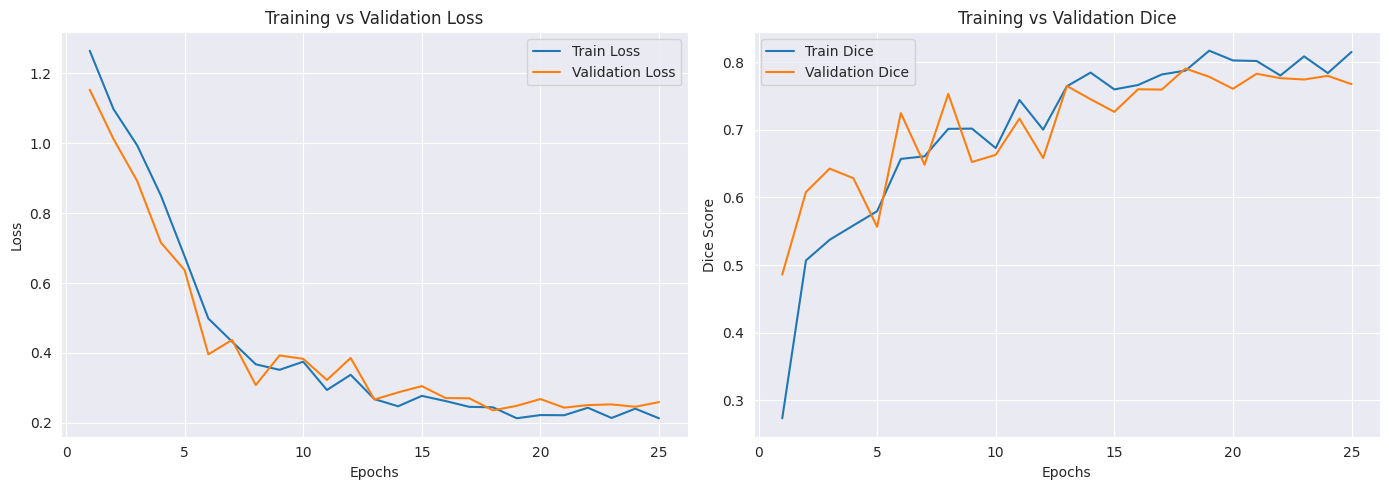

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(14,5))

# 🔹 LOSS CURVE
plt.subplot(1,2,1)
sns.lineplot(x=epochs, y=train_losses, label="Train Loss")
sns.lineplot(x=epochs, y=val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# 🔹 DICE CURVE
plt.subplot(1,2,2)
sns.lineplot(x=epochs, y=train_dices, label="Train Dice")
sns.lineplot(x=epochs, y=val_dices, label="Validation Dice")
plt.xlabel("Epochs")
plt.ylabel("Dice Score")
plt.title("Training vs Validation Dice")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
model.load_state_dict(torch.load("best_unet_model.pth", map_location=DEVICE))
model.eval()
print("Best model loaded")


Best model loaded


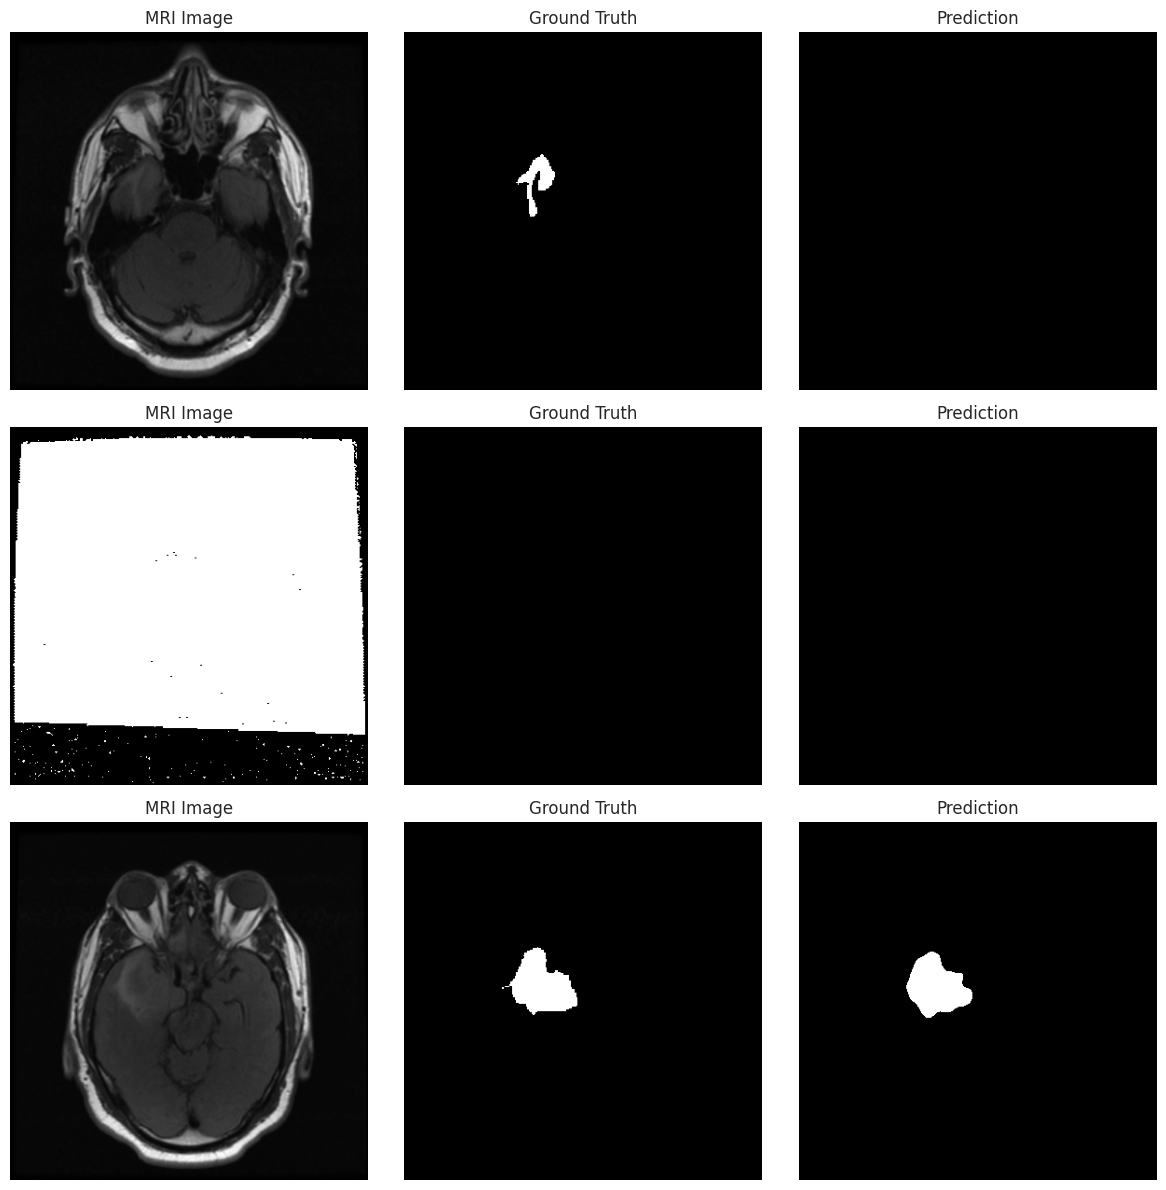

In [ ]:
images, masks = next(iter(val_loader))
images = images.to(DEVICE)
masks = masks.to(DEVICE)

with torch.no_grad():
    preds = torch.sigmoid(model(images))
    preds = (preds > 0.5).float()

num_samples = images.size(0)  # <-- dynamic batch size
num_samples = min(num_samples, 3)

plt.figure(figsize=(12, 4*num_samples))

for i in range(num_samples):
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(images[i][0].cpu(), cmap='gray')
    plt.title("MRI Image")
    plt.axis('off')

    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(masks[i][0].cpu(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(preds[i][0].cpu(), cmap='gray')
    plt.title("Prediction")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
test_dataset = Neuroseg(test_df, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [ ]:
test_dice = 0.0
test_iou = 0.0
test_sensitivity = 0.0
tumor_areas = []

model.eval()

with torch.no_grad():
    for images, masks in tqdm(test_loader, desc="Testing"):

        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        outputs = model(images)

        dice, iou, sens = get_metrics(outputs, masks)

        test_dice += dice
        test_iou += iou
        test_sensitivity += sens

        # Tumor area calculation
        preds = torch.sigmoid(outputs)
        area = calculate_tumor_area(preds)
        tumor_areas.append(area)

# Average metrics
test_dice /= len(test_loader)
test_iou /= len(test_loader)
test_sensitivity /= len(test_loader)

print("\n🎯 TEST RESULTS")
print(f"Dice Score: {test_dice:.4f}")
print(f"IoU Score: {test_iou:.4f}")
print(f"Sensitivity: {test_sensitivity:.4f}")
print(f"Average Tumor Area: {np.mean(tumor_areas):.2f} pixels")


Testing: 100%|██████████| 71/71 [00:13<00:00,  5.19it/s]


🎯 TEST RESULTS
Dice Score: 0.7151
IoU Score: 0.6154
Sensitivity: 0.7281
Average Tumor Area: 15195.85 pixels


In [ ]:
import matplotlib.pyplot as plt
import torch
import random

def visualize_predictions(model, dataloader, device, num_samples=10, threshold=0.5):
    model.eval()

    # Get one batch
    images, masks = next(iter(dataloader))

    # Move to device
    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > threshold).float()

    # Randomly select indices from batch
    indices = random.sample(range(images.size(0)), num_samples)

    for i in indices:
        img = images[i].cpu().squeeze()
        true_mask = masks[i].cpu().squeeze()
        pred_mask = preds[i].cpu().squeeze()

        plt.figure(figsize=(12,4))

        # Original Image
        plt.subplot(1,3,1)
        plt.imshow(img, cmap='gray')
        plt.title("Original Image")
        plt.axis('off')

        # Ground Truth
        plt.subplot(1,3,2)
        plt.imshow(true_mask, cmap='gray')
        plt.title("Ground Truth Mask")
        plt.axis('off')

        # Prediction
        plt.subplot(1,3,3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


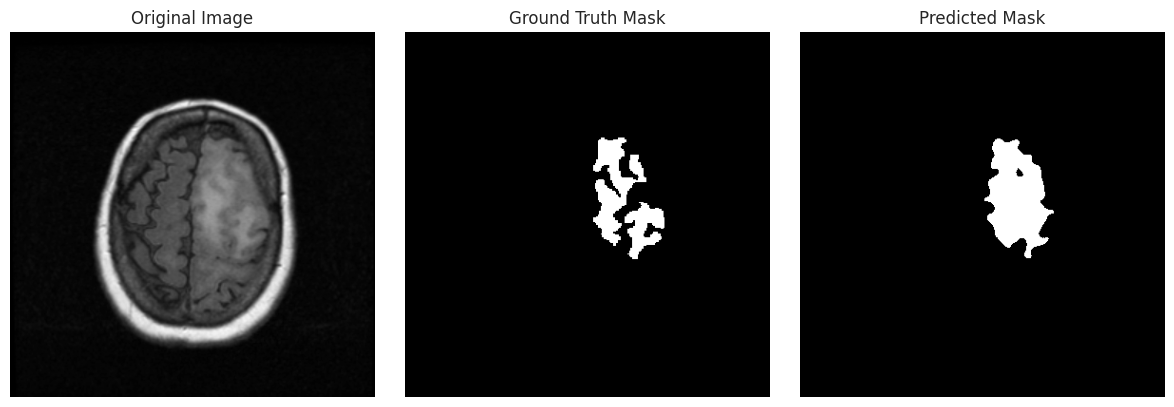

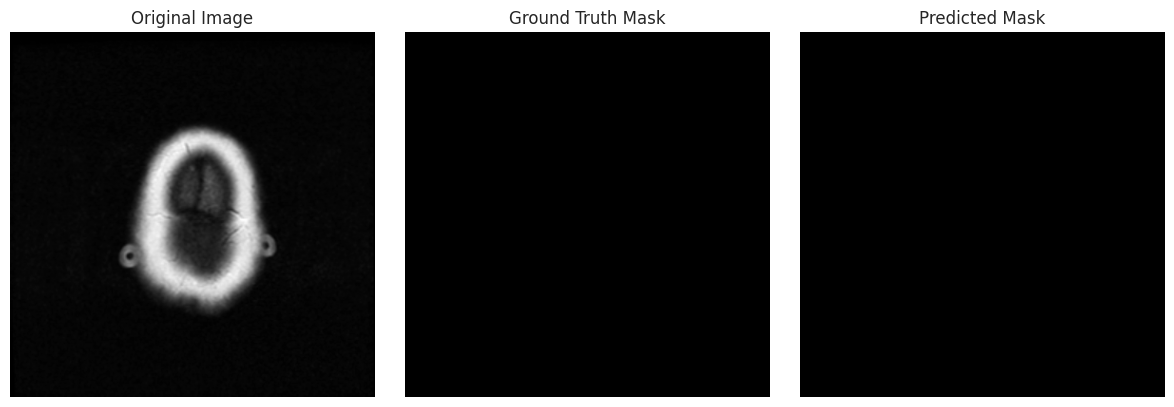

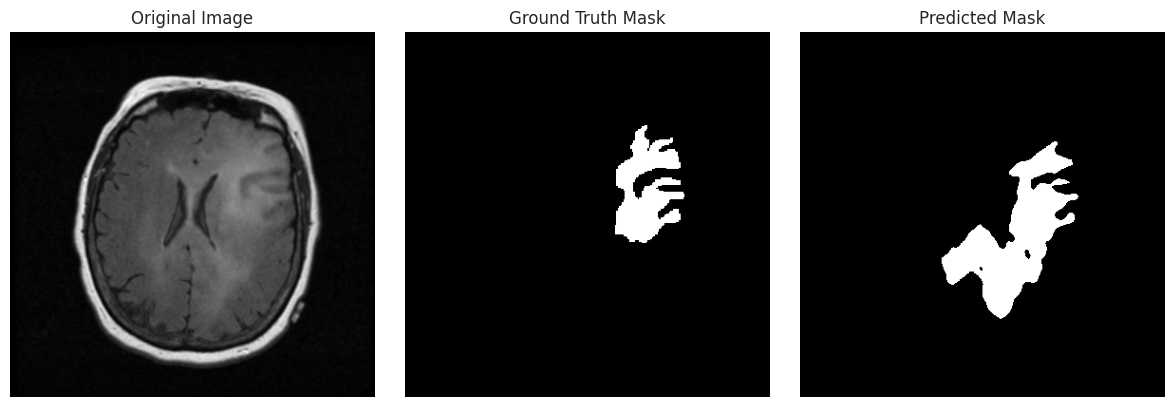

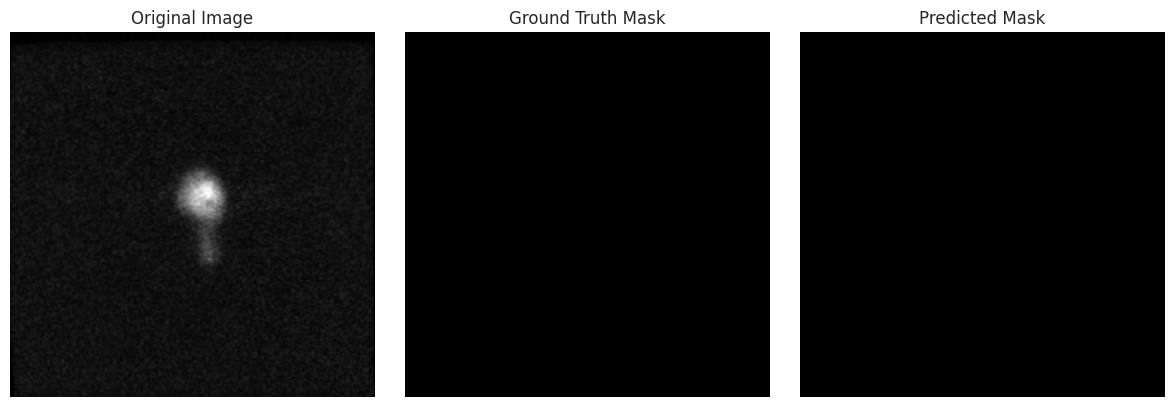

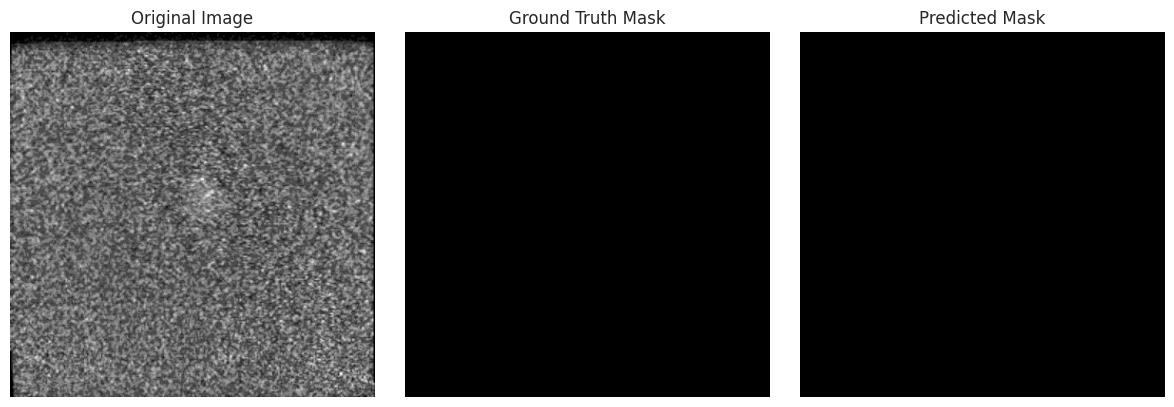

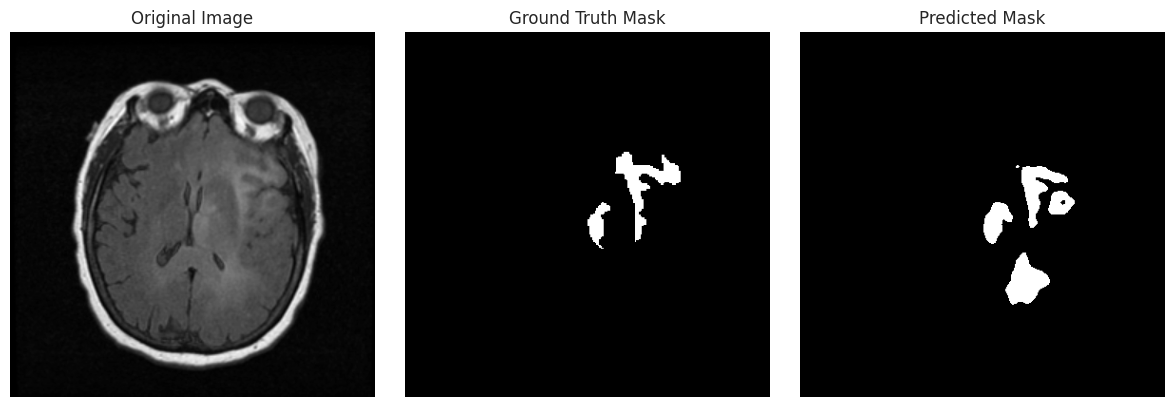

In [ ]:
visualize_predictions(model, test_loader, DEVICE, num_samples=6, threshold=0.5)


In [ ]:
pip freeze > requirements.txt